# 04 · Desempeño de las predicciones y de la lógica de eventos

Compara `predictions.jsonl` y `events.jsonl` con la verdad terreno (`ground_truth.jsonl`, `ground_truth_events.jsonl`).
Incluye análisis de errores, y **experimentos** para el reporte: estrategias de decisión y resoluciones de entrada distintas.

> Los eventos esperados que produce `build_ground_truth.py --derive-events` salen de aplicar las reglas a tus anotaciones.
> Revísalos manualmente antes de llamarlos «verdad terreno revisada».

In [1]:
import sys
from pathlib import Path

_nb = Path.cwd() if (Path.cwd() / "helpers.py").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(_nb))
from helpers import *   # utilidades compartidas (pd, plt, np, run, read_json, show_images...)

REPO = setup()          # cambia el directorio de trabajo a la raíz del repo
print("Repositorio:", REPO)

Repositorio: /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision


In [2]:
DATASET_ROOT = env("DATASET_ROOT", "src/data/kaggle_dataset")
RUN_DIR      = env("RUN_DIR", "outputs/latest")
GT_DIR       = env("GT_DIR", "data/ground_truth")
EVAL_DIR     = env("EVAL_DIR", "reports/evaluation")
SPLIT_DIR    = env("SPLIT_DIR", f"{DATASET_ROOT}/test")     # partición con etiquetas para la verdad terreno
CONF_OP      = 0.25      # punto de operación para P/R/F1
IOU          = 0.5
SAMPLE       = 0         # 0 = toda la partición; N = muestra revisada de N imágenes
RUN_BUILD_GT = True
RUN_EVAL     = True

In [3]:
py = sys.executable
if RUN_BUILD_GT or not (Path(GT_DIR) / "ground_truth.jsonl").exists():
    cmd = [py, "src/build_ground_truth.py", "--split-dir", SPLIT_DIR, "--dataset-root", DATASET_ROOT,
           "--out", GT_DIR, "--derive-events"]
    if SAMPLE:
        cmd += ["--sample", SAMPLE]
    run(cmd)
ready = exists_or_hint(Path(RUN_DIR) / "predictions.jsonl", "Ejecuta primero la inferencia (notebook 03 o src/inference.py).")
if ready and RUN_EVAL:
    run([py, "src/evaluate_predictions.py", "--predictions", Path(RUN_DIR) / "predictions.jsonl",
         "--ground-truth", Path(GT_DIR) / "ground_truth.jsonl", "--events", Path(RUN_DIR) / "events.jsonl",
         "--ground-truth-events", Path(GT_DIR) / "ground_truth_events.jsonl",
         "--images-index", Path(RUN_DIR) / "images_index.jsonl", "--out", EVAL_DIR, "--iou", IOU, "--conf", CONF_OP])

$ /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/.venv/bin/python src/build_ground_truth.py --split-dir src/data/kaggle_dataset/test --dataset-root src/data/kaggle_dataset --out data/ground_truth --derive-events
2026-10-09 23:10:57,706 INFO Imágenes: 406 | anotaciones: 2785 | eventos esperados: 605 -> data/ground_truth
$ /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/.venv/bin/python src/evaluate_predictions.py --predictions outputs/latest/predictions.jsonl --ground-truth data/ground_truth/ground_truth.jsonl --events outputs/latest/events.jsonl --ground-truth-events data/ground_truth/ground_truth_events.jsonl --images-index outputs/latest/images_index.jsonl --out reports/evaluation --iou 0.5 --conf 0.25
2026-10-09 23:11:01,123 INFO Imágenes revisadas: 406 | objetos GT: 2785 | predicciones en alcance: 2811
2026-10-09 23:11:01,123 INFO micro P=0.830 R=0.838 F1=0.834 | mAP50=0.8027 mAP50-95=0.5316 | eviden

## 1. Alcance de la evaluación y métricas por clase

In [4]:
pm = read_json(Path(EVAL_DIR) / "prediction_metrics.json")
print(pm["scope"])
display(pd.DataFrame(pm["per_class"]).T)
g = pm["global"]
print("micro:", g["micro"]); print("macro:", g["macro"]); print("mAP@0.5:", g["map50"], "| mAP@0.5:0.95:", g["map50_95"])
print("\n* mAP calculado con todas las predicciones guardadas; si la inferencia usó un umbral alto, queda truncado.")

{'labeled_images': 406, 'scope_defined_by_image_records': True, 'gt_objects': 2785, 'predictions_in_scope': 2811, 'note': 'Las métricas sólo cubren las imágenes revisadas; predicciones en otras imágenes se ignoran. mAP usa todas las predicciones guardadas: si la inferencia usó un umbral alto, el mAP queda truncado.'}


,gt_objects,predictions,tp,fp,fn,precision,recall,f1,ap50,ap50_95
helmet,529.0,521.0,449.0,72.0,80.0,0.8618,0.8488,0.8552,0.8236,0.5351
no_helmet,393.0,425.0,304.0,121.0,89.0,0.7153,0.7735,0.7433,0.7249,0.4180
no_vest,513.0,565.0,418.0,147.0,95.0,0.7398,0.8148,0.7755,0.7665,0.4543
person,954.0,906.0,817.0,89.0,137.0,0.9018,0.8564,0.8785,0.8380,0.6409
vest,396.0,394.0,345.0,49.0,51.0,0.8756,0.8712,0.8734,0.8603,0.6096


micro: {'tp': 2333, 'fp': 478, 'fn': 452, 'precision': 0.83, 'recall': 0.8377, 'f1': 0.8338}
macro: {'precision': 0.8189, 'recall': 0.8329, 'f1': 0.8252}
mAP@0.5: 0.8027 | mAP@0.5:0.95: 0.5316

* mAP calculado con todas las predicciones guardadas; si la inferencia usó un umbral alto, queda truncado.


## 2. Imágenes sin detecciones y anotaciones sin predicción

In [5]:
print("Imágenes con objetos reales y cero predicciones:", pm["images_without_detections"]["count"])
print("   ", pm["images_without_detections"]["meaning"])
print("Imágenes sin objetos reales pero con predicciones:", pm["images_with_predictions_but_no_objects"]["count"])
print("   ", pm["images_with_predictions_but_no_objects"]["meaning"])
print("Anotaciones sin predicción (FN):", pm["annotations_without_prediction"]["count"])

Imágenes con objetos reales y cero predicciones: 7
    imágenes con objetos reales y cero predicciones: cada objeto cuenta como FN
Imágenes sin objetos reales pero con predicciones: 0
    imágenes sin objetos reales con predicciones: todas son FP
Anotaciones sin predicción (FN): 452


## 3. Causas probables de los errores

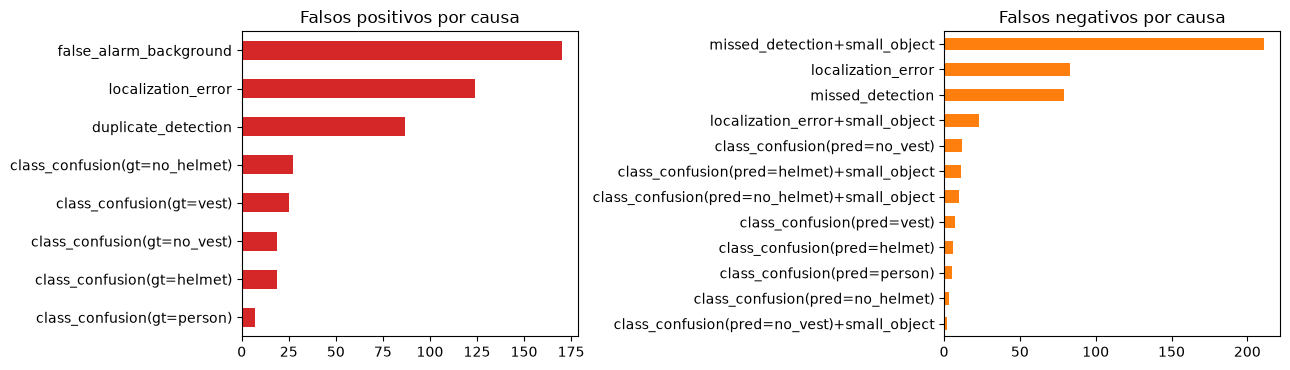

In [6]:
fp = pd.Series(pm["false_positive_causes"], name="FP").sort_values()
fn = pd.Series(pm["annotations_without_prediction"]["by_cause"], name="FN").sort_values()
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
fp.plot.barh(ax=ax[0], color="tab:red", title="Falsos positivos por causa")
fn.plot.barh(ax=ax[1], color="tab:orange", title="Falsos negativos por causa")
plt.tight_layout(); plt.show()

In [7]:
errors = read_jsonl_df(Path(EVAL_DIR) / "errors.jsonl")
if len(errors):
    display(errors.groupby(["type", "class", "cause"]).size().rename("n").reset_index().sort_values("n", ascending=False).head(15))

,type,class,cause,n
13,FN,no_helmet,missed_detection+small_object,53
6,FN,helmet,missed_detection+small_object,51
40,FP,no_helmet,false_alarm_background,51
46,FP,no_vest,false_alarm_background,50
25,FN,person,missed_detection+small_object,48
22,FN,person,localization_error,44
24,FN,person,missed_detection,40
19,FN,no_vest,missed_detection+small_object,37
47,FP,no_vest,localization_error,36
51,FP,person,false_alarm_background,36


## 4. Matriz de confusión, curva PR y ejemplos de error

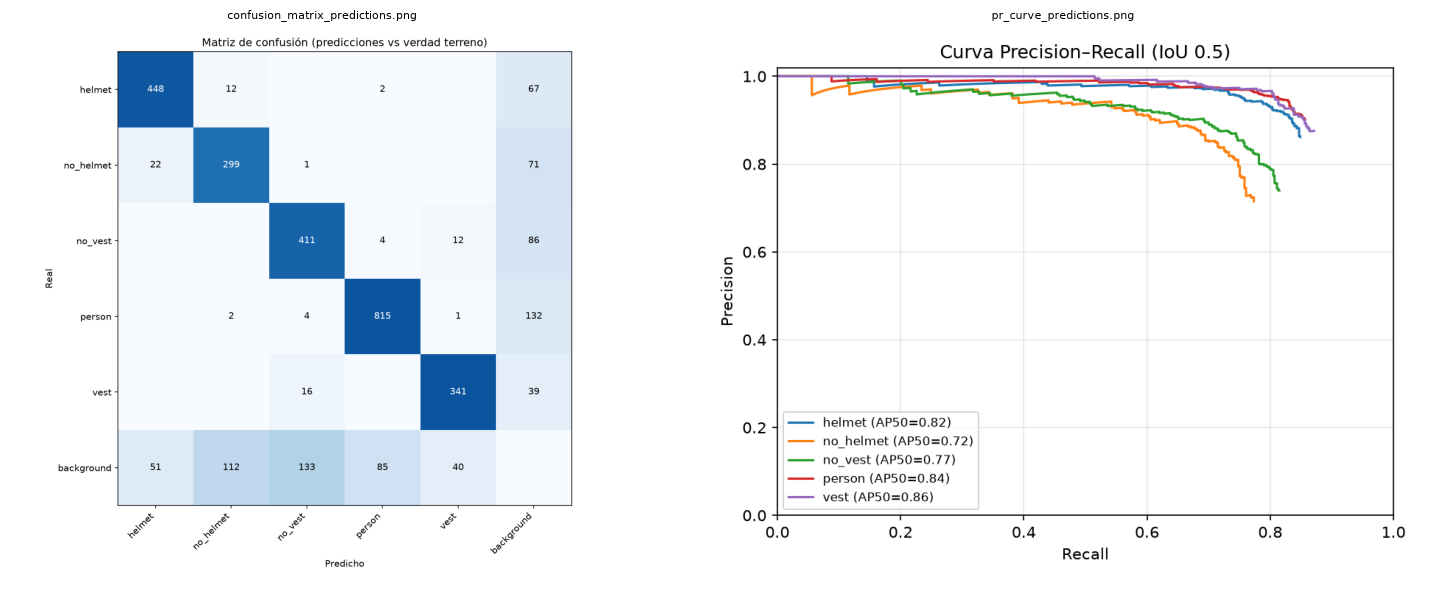

In [8]:
show_images([Path(EVAL_DIR) / "confusion_matrix_predictions.png", Path(EVAL_DIR) / "pr_curve_predictions.png"],
            cols=2, size=(7.5, 6))

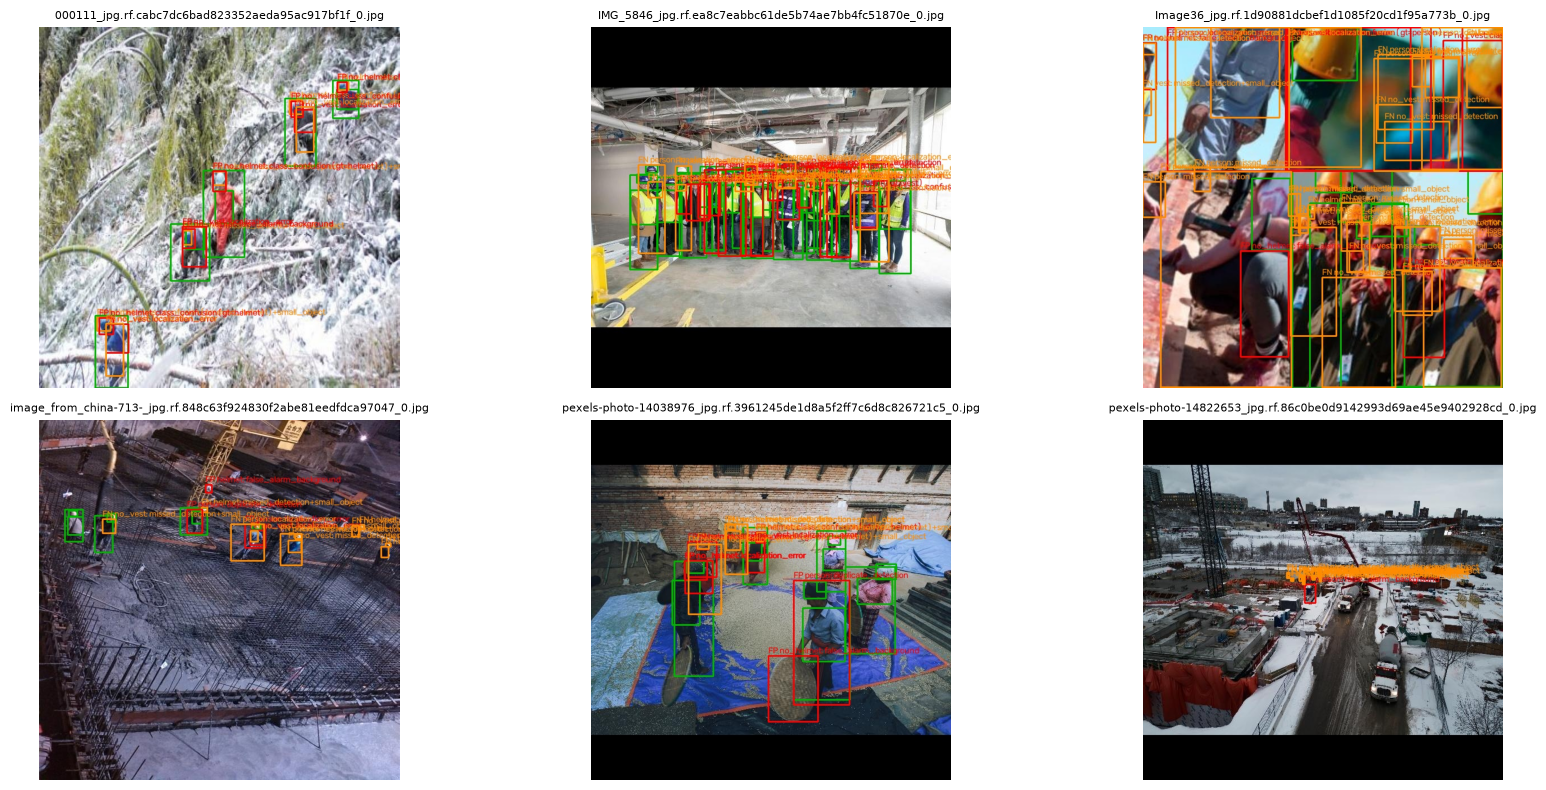

In [9]:
ex = sorted((Path(EVAL_DIR) / "error_examples").glob("*.jpg"))[:6]
show_images(ex, cols=3, size=(6, 4))   # verde = verdad terreno · rojo = FP · naranja = FN

### Errores representativos (completar para el reporte, sección 8.1)

| Imagen | Tipo | Clase | Causa probable | Mejora |
|---|---|---|---|---|
| _<>_ | FP/FN | _<>_ | _<>_ | _<>_ |

## 5. Desempeño de la lógica de eventos

In [10]:
em = read_json(Path(EVAL_DIR) / "event_metrics.json")
print("Conteos:", em["counts"])
print("Global (duplicados cuentan como FP):", em["overall"])
print("Global (duplicados aparte):         ", em["overall_excluding_duplicates_as_fp"])
print("Tasa de duplicidad:", em["duplicate_rate"])
print("Omitidos por causa:", em["missed_events"]["by_cause"])
print("Latencia (s):", em["latency_seconds"])

Conteos: {'predicted_events': 655, 'expected_events': 605, 'matched': 455, 'duplicates': 4, 'false_positives': 196, 'missed': 150}
Global (duplicados cuentan como FP): {'tp': 455, 'fp': 200, 'fn': 150, 'precision': 0.6947, 'recall': 0.7521, 'f1': 0.7222}
Global (duplicados aparte):          {'tp': 455, 'fp': 196, 'fn': 150, 'precision': 0.6989, 'recall': 0.7521, 'f1': 0.7245}
Tasa de duplicidad: 0.0061
Omitidos por causa: {'wrong_event_type_or_severity': 92, 'no_event_generated(detección_o_regla)': 58}
Latencia (s): {'pipeline_condition_to_event': {'count': 455, 'mean': 0.0, 'median': 0.0, 'p95': 0.0, 'max': 0.0}, 'event_vs_ground_truth_timestamp': {'count': 455, 'mean': 0.0, 'median': 0.0, 'p95': 0.0, 'max': 0.0}}


In [11]:
for key in ("by_event_type", "by_camera"):
    if em[key]:
        print(f"\n--- {key} ---")
        display(pd.DataFrame(em[key]).T)


--- by_event_type ---


,tp,fp,fn,precision,recall,f1
persona_sin_casco,86.0,31.0,32.0,0.7350,0.7288,0.7319
persona_sin_casco_y_chaleco,209.0,111.0,48.0,0.6531,0.8132,0.7244
persona_sin_chaleco,160.0,54.0,70.0,0.7477,0.6957,0.7207



--- by_camera ---


,tp,fp,fn,precision,recall,f1
CAM_01,455.0,196.0,150.0,0.6989,0.7521,0.7245


## 6. Experimentos para el reporte

Requieren `models/best_model.pt` y `ultralytics`. Cada experimento ejecuta inferencia + verdad terreno + evaluación y guarda sus resultados en `outputs/exp_<nombre>/` y `reports/experiments/<nombre>/`.
`*` mAP truncado por el punto de operación (umbral de confianza).

In [12]:
RUN_EXPERIMENTS = False     # True: ejecuta los experimentos de abajo
SUBSET = 100                # imágenes por experimento (0 = todas)
dataset_root = Path(DATASET_ROOT)

### 6.1 Estrategia de decisión: `association` vs `explicit` vs `hybrid`

In [13]:
if RUN_EXPERIMENTS:
    src_images = Path(SPLIT_DIR) / "images"
    rows = [run_experiment(f"estrategia_{s}", src_images, Path(SPLIT_DIR), dataset_root, CONF_OP,
                           rules_args=[f"decision.strategy={s}"]) for s in ("association", "explicit", "hybrid")]
    strategies = pd.DataFrame(rows).set_index("experimento")
    display(strategies)

### 6.2 Resoluciones distintas a las del entrenamiento y modos de adaptación
Se reescala la partición de prueba a varios tamaños (lado mayor) y se compara `letterbox`, `resize` y `none`.

In [14]:
if RUN_EXPERIMENTS:
    rows = []
    for side in (320, 640, 1280, 1920):
        resized_root = Path(f"data/resolution_tests/{side}")
        split = make_resized_split(Path(SPLIT_DIR), resized_root, side, SUBSET)
        for mode in ("letterbox", "resize", "none"):
            r = run_experiment(f"res{side}_{mode}", split / "images", split, resized_root, CONF_OP,
                               inference_args=["--resize-mode", mode])
            r.update({"lado mayor (px)": side, "modo": mode})
            rows.append(r)
    resolution = pd.DataFrame(rows).set_index(["lado mayor (px)", "modo"]).drop(columns="experimento")
    display(resolution)

In [15]:
if RUN_EXPERIMENTS:
    pivot = resolution["F1 eventos"].unstack("modo")
    pivot.plot(marker="o", figsize=(7, 4), title="F1 de eventos según resolución y modo de adaptación")
    plt.ylabel("F1"); plt.xlabel("lado mayor de la imagen (px)"); plt.grid(alpha=0.3); plt.show()

## 7. Conclusiones (completar para el reporte, secciones 5.1, 6.2 y 8)

- Estrategia de decisión elegida y por qué: _<>_
- Modo de adaptación de resolución elegido y por qué: _<>_
- Principales causas de error y su mitigación: _<>_
- Limitaciones de la verdad terreno: _<tamaño, selección, eventos derivados>_